In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df= pd.read_csv("/content/drive/MyDrive/datasets/titanic.csv")

In [25]:
df["Age"]=df["Age"].fillna(df["Age"].median())
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
df=df.drop(columns=["Cabin"])

In [26]:
df=df.drop(columns=["PassengerId","Name","Ticket"])

In [27]:
df=pd.get_dummies(df,columns=["Sex", "Embarked"], drop_first=True)

In [28]:
x=df.drop("Survived", axis=1)
y=df["Survived"]

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [31]:
y_pred =model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [32]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[90 15]
 [19 55]]


In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



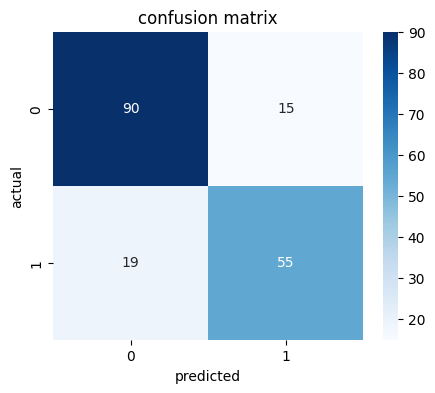

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",cmap="Blues")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix")
plt.show()

The confusion matrix shows how well the Logistic Regression model classified passengers. The diagonal values represent correct predictions, while the off-diagonal values represent incorrect predictions. A higher number of correct predictions indicates better model performance. The model achieved good accuracy with relatively few misclassifications. The Logistic Regression model achieved an accuracy of approximately 81%, meaning it correctly predicted the survival outcome for about 81% of passengers in the test dataset.